In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
import os
import numpy as np

In [2]:
FILE_PATH = '../../../../cyberbullying_tweets_classifiers.csv'
df = pd.read_csv(FILE_PATH)
df = df.dropna(how='any')
df.head()

,text,type,label
0,rape realzvasiyana enema joke drunk gay lesbia...,gender,0
1,never saw celebrity say anything like obama b ...,gender,0
2,user mean gay us gendered slur make rape joke,gender,0
3,between user user user user feminacy,gender,0
4,rape rape fact read one post guy getting raped...,gender,0


In [3]:
label_to_type = df.groupby('label')['type'].first().to_dict()
target_names = [label_to_type[i] for i in sorted(label_to_type.keys())]

In [4]:
base_path = "../../../../Embeddings/TF-IDF/Data"

X_train = joblib.load(os.path.join(base_path, "X_train_tfidf_1.pkl"))
X_test = joblib.load(os.path.join(base_path, "X_test_tfidf_1.pkl"))
y_train = joblib.load(os.path.join(base_path, "y_train_tfidf_1.pkl"))
y_test = joblib.load(os.path.join(base_path, "y_test_tfidf_1.pkl"))

In [5]:
print("Distribuție înainte de oversampling:", Counter(y_train))

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Distribuție după oversampling:", Counter(y_train_resampled))

Distribuție înainte de oversampling: Counter({1: 6369, 3: 6308, 4: 6251, 0: 6191, 2: 5943})
Distribuție după oversampling: Counter({1: 6369, 3: 6369, 2: 6369, 4: 6369, 0: 6369})


In [6]:
model = MultinomialNB(alpha=1.0)  
model.fit(X_train_resampled, y_train_resampled)

MultinomialNB()

In [7]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.89      0.85      0.87      1548
           religion       0.91      0.96      0.94      1592
other_cyberbullying       0.80      0.76      0.78      1486
                age       0.92      0.98      0.95      1577
          ethnicity       0.92      0.90      0.91      1563

           accuracy                           0.89      7766
          macro avg       0.89      0.89      0.89      7766
       weighted avg       0.89      0.89      0.89      7766



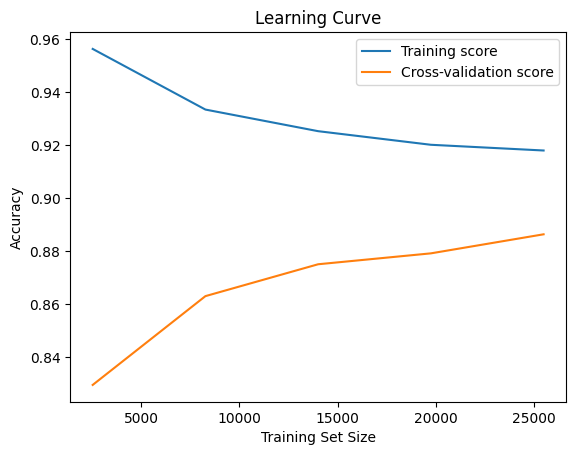

In [8]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_resampled, y_train_resampled,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5, scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

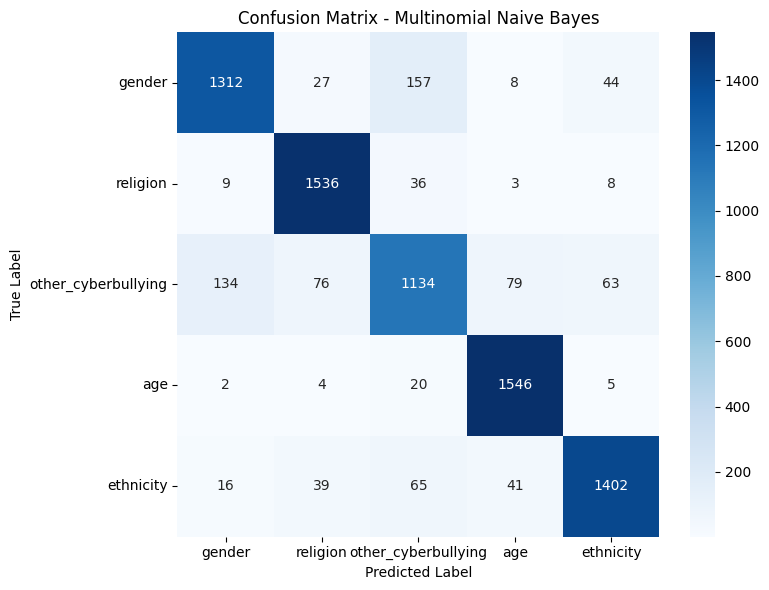

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

In [10]:
#count vectorizer
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df = df[df['word_count'] >= 2]

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [11]:
count_vect = CountVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words='english',
    min_df=2
)

X_train_counts = count_vect.fit_transform(X_train.astype('U'))
X_test_counts = count_vect.transform(X_test.astype('U'))

In [12]:
print("Distribuție înainte de oversampling:", Counter(y_train))

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_counts, y_train)

print("Distribuție după oversampling:", Counter(y_train_resampled))

Distribuție înainte de oversampling: Counter({1: 6369, 3: 6308, 4: 6251, 0: 6191, 2: 5943})
Distribuție după oversampling: Counter({1: 6369, 3: 6369, 2: 6369, 4: 6369, 0: 6369})


In [13]:
model = MultinomialNB()
model.fit(X_train_resampled, y_train_resampled)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test_counts)

print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.91      0.81      0.86      1548
           religion       0.94      0.96      0.95      1592
other_cyberbullying       0.77      0.82      0.79      1486
                age       0.94      0.98      0.96      1577
          ethnicity       0.94      0.91      0.92      1563

           accuracy                           0.90      7766
          macro avg       0.90      0.90      0.90      7766
       weighted avg       0.90      0.90      0.90      7766



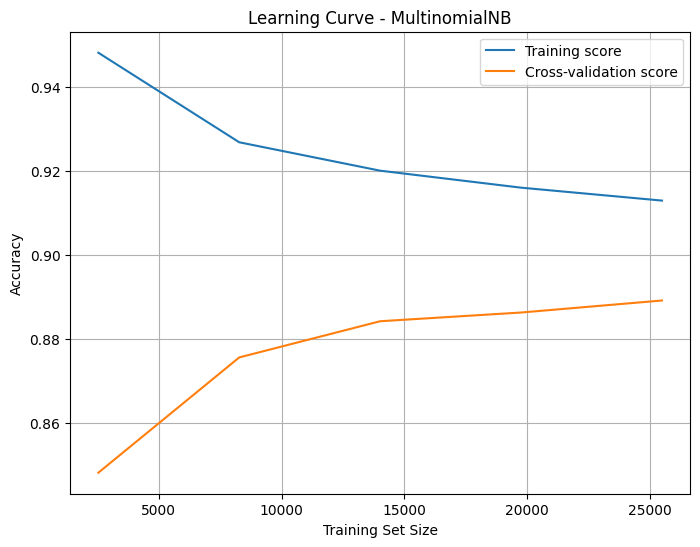

In [20]:
train_sizes, train_scores, test_scores = learning_curve(
    model, 
    X_train_resampled, 
    y_train_resampled,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='accuracy',
    n_jobs=-1 
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - MultinomialNB')
plt.legend(loc='best')
plt.grid(True)
plt.show()

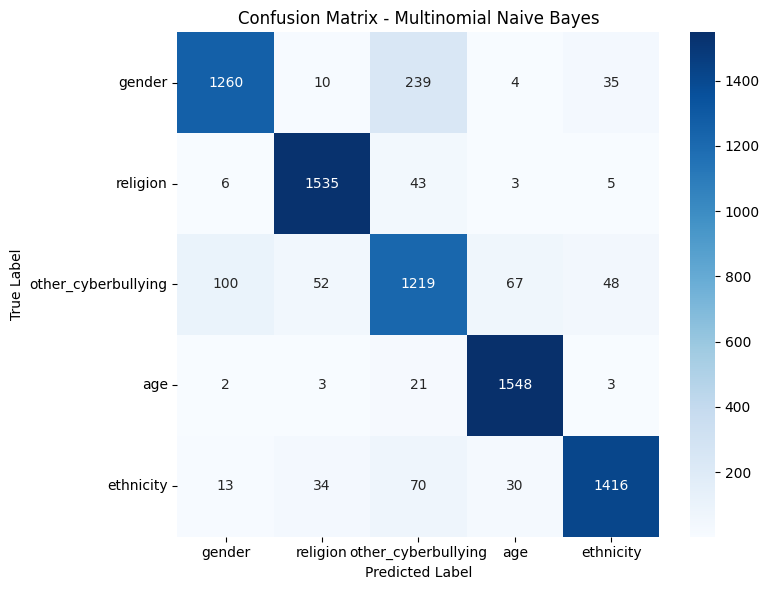

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

In [30]:
texts = [
    "You are muslim you don't have opinion",
    "You are just a little girl!",
    "Nigga",
    "Boy"
]

texts_vect = count_vect.transform(texts)
labels_pred = model.predict(texts_vect)

for text, label in zip(texts, labels_pred):
    print(f"Text: {text}\nPredicted type: {label_to_type[label]}\n")

Text: You are muslim you don't have opinion
Predicted type: religion

Text: You are just a little girl!
Predicted type: age

Text: Nigga
Predicted type: gender

Text: Boy
Predicted type: age



In [31]:
joblib.dump(model, 'naive_bayes_model.pkl')
joblib.dump(count_vect, 'count_vectorizer.pkl')

['count_vectorizer.pkl']